<a href="https://colab.research.google.com/github/mugoyashariff/Towards-Explainable-and-Interpretable-Machine-Learning-in-Smart-Grids-in-Developing-Countries/blob/main/Dataset_Location.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


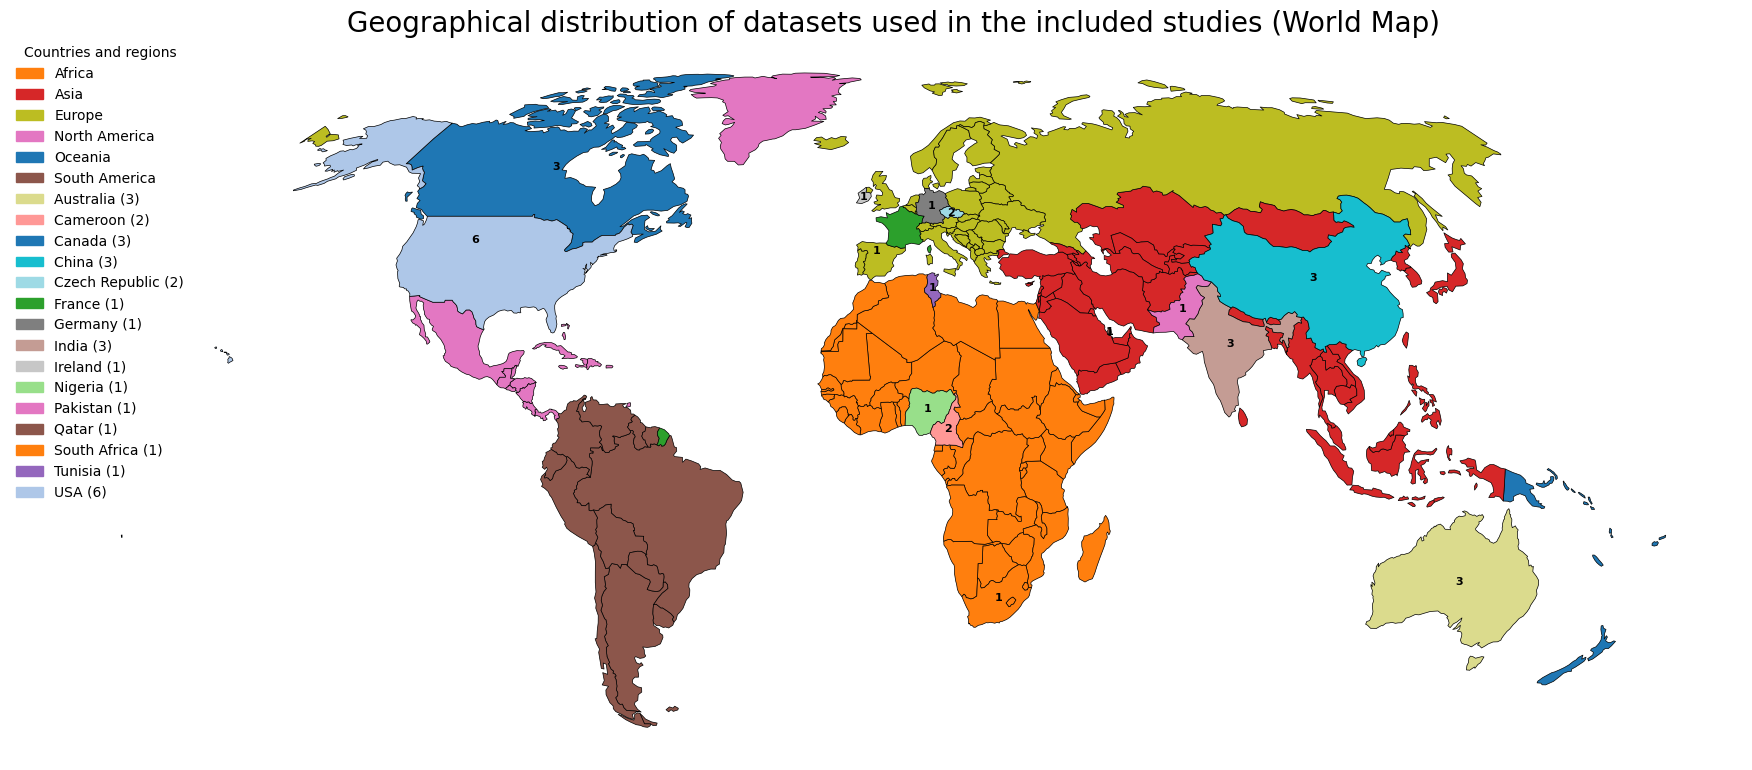

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # For custom legend
# from mpl_toolkits.axes_grid1 import make_axes_locatable # Not needed if colorbar is removed
import matplotlib.cm as cm # Still useful for get_cmap

import os
from google.colab import drive
drive.mount('/content/drive')
root_dir = "/content/drive/MyDrive/Colab Notebooks/Datasets used.xlsx" # Corrected path
df_articles = pd.read_excel(root_dir)

# Standardize country names in df_articles before processing
country_name_mapping = {
    'United states of America': 'USA',
    'Czech Republic': 'Czech Republic',
    'United States': 'USA',
    'Czechia': 'Czech Republic'
    # Add more mappings here if other names are mismatched
}
df_articles['Country'] = df_articles['Country'].replace(country_name_mapping)

# Prepare the counts DataFrame from df_articles
counts = df_articles.rename(columns={'Country': 'name', 'Number of datasets': 'count'})

# Load world map
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# --- New step: Standardize country names in the world GeoDataFrame ---
# This mapping converts common geopandas names to the standardized names in df_articles
world_name_standardization_map = {
    'United States of America': 'USA', # Common geopandas name for USA
    'United States': 'USA',
    'Czech Rep.': 'Czech Republic', # Common geopandas name for Czech Republic
    'Czechia': 'Czech Republic' # Added to handle 'Czechia' if present in world GeoDataFrame
}
# Apply this standardization to the 'NAME' column of the world GeoDataFrame
world['NAME'] = world['NAME'].replace(world_name_standardization_map)

# --- 2. Reprojection & Optimization ---
# Reproject to a more "filled" projection (Robinson is great for maps)
world = world.to_crs("ESRI:54030")

# Merge counts with world map
world = world.merge(counts, how="left", left_on="NAME", right_on="name")

# Separate countries with and without data
world_with_data = world[world['count'].notna()].copy() # Use .copy() to avoid SettingWithCopyWarning
world_no_data = world[world['count'].isna()].copy() # Use .copy()

# Assign colors to continents for countries without data
# Get unique continents from the no_data subset, excluding None, 'Antarctica', and 'Seven seas (open ocean)'
unique_continents_no_data = [c for c in world_no_data['CONTINENT'].unique() if c is not None and c != 'Antarctica' and c != 'Seven seas (open ocean)']

# Define a color map for continents (ensure enough distinct colors)
cmap_no_data = plt.get_cmap('tab10') # You can change this colormap if needed
continent_colors = {continent: cmap_no_data(i / len(unique_continents_no_data))
                    for i, continent in enumerate(unique_continents_no_data)}

# Assign the colors to the no-data countries
world_no_data['continent_color'] = world_no_data['CONTINENT'].map(continent_colors)

# Assign unique colors to countries with data
num_data_countries = len(world_with_data)
if num_data_countries > 0:
    # Use 'tab20' colormap, which provides 20 distinct colors. If more countries, colors will repeat.
    cmap_data_countries = plt.get_cmap('tab20', num_data_countries)
    world_with_data['unique_data_color'] = [cmap_data_countries(i) for i in range(num_data_countries)]
else:
    world_with_data['unique_data_color'] = [] # Handle case with no data countries

# --- 3. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot countries with NO data, colored by continent
# Exclude Antarctica and 'Seven seas (open ocean)' from being plotted with a continent color
world_no_data_for_plot = world_no_data[(world_no_data['CONTINENT'] != 'Antarctica') & (world_no_data['CONTINENT'] != 'Seven seas (open ocean)')]
world_no_data_for_plot.plot(color=world_no_data_for_plot['continent_color'],
                   ax=ax,
                   edgecolor='black',
                   linewidth=0.5)

# Plot countries WITH data on top, using their unique assigned color
if not world_with_data.empty:
    world_with_data.plot(color=world_with_data['unique_data_color'],
                         ax=ax,
                         edgecolor='black',
                         linewidth=0.5)


# Annotate each country with data (number of datasets)
for idx, row in world_with_data.iterrows():
    if pd.notna(row['count']) and row['count'] > 0:
        centroid = row['geometry'].centroid
        plt.annotate(text=int(row['count']),
                     xy=(centroid.x, centroid.y),
                     ha='center', va='center',
                     fontsize=8, color='black', fontweight='bold')

# --- Legend Creation ---
# Create custom legend patches for continents (no data)
all_patches = []
for continent in sorted(unique_continents_no_data):
    color = continent_colors[continent]
    all_patches.append(mpatches.Patch(color=color, label=f'{continent}'))

# Add legend entries for countries with data
if not world_with_data.empty:
    # Sort countries by name for consistent legend order
    sorted_world_with_data = world_with_data.sort_values(by='NAME')
    for idx, row in sorted_world_with_data.iterrows():
        country_name = row['NAME'] # Using 'NAME' from geopandas for country name
        country_color = row['unique_data_color']
        all_patches.append(mpatches.Patch(color=country_color, label=f'{country_name} ({int(row["count"])})')) # Include count in label

# Add the combined legend to the plot
ax.legend(handles=all_patches,
          title="Countries and regions", # Changed title as requested
          loc='upper left', # Position relative to the main axes
          bbox_to_anchor=(-0.02, 1), # Adjust to place outside the map on the left
          borderaxespad=0.,
          frameon=False) # Make legend background transparent


# --- 4. Final Formatting ---
ax.set_title('Geographical distribution of datasets used in the included studies (World Map)', fontsize=20)
ax.set_axis_off()  # Removes the frame and ticks completely

plt.tight_layout(rect=[0.12, 0, 1, 1]) # Adjust rect for the legend space on the left
plt.show()